In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline


In [2]:
ei=pd.read_csv(r'..\data\economic_index.csv')
ei.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [3]:
# deleting the unnecessary columns
ei.drop(columns=['Unnamed: 0','month'],axis=1,inplace=True)

In [4]:
ei.head()

,year,interest_rate,unemployment_rate,index_price
0,2017,2.75,5.3,1464
1,2017,2.50,5.3,1394
2,2017,2.50,5.3,1357
3,2017,2.50,5.3,1293
4,2017,2.50,5.4,1256


In [5]:
#check null value have or not
ei.isnull().sum()

year                 0
interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

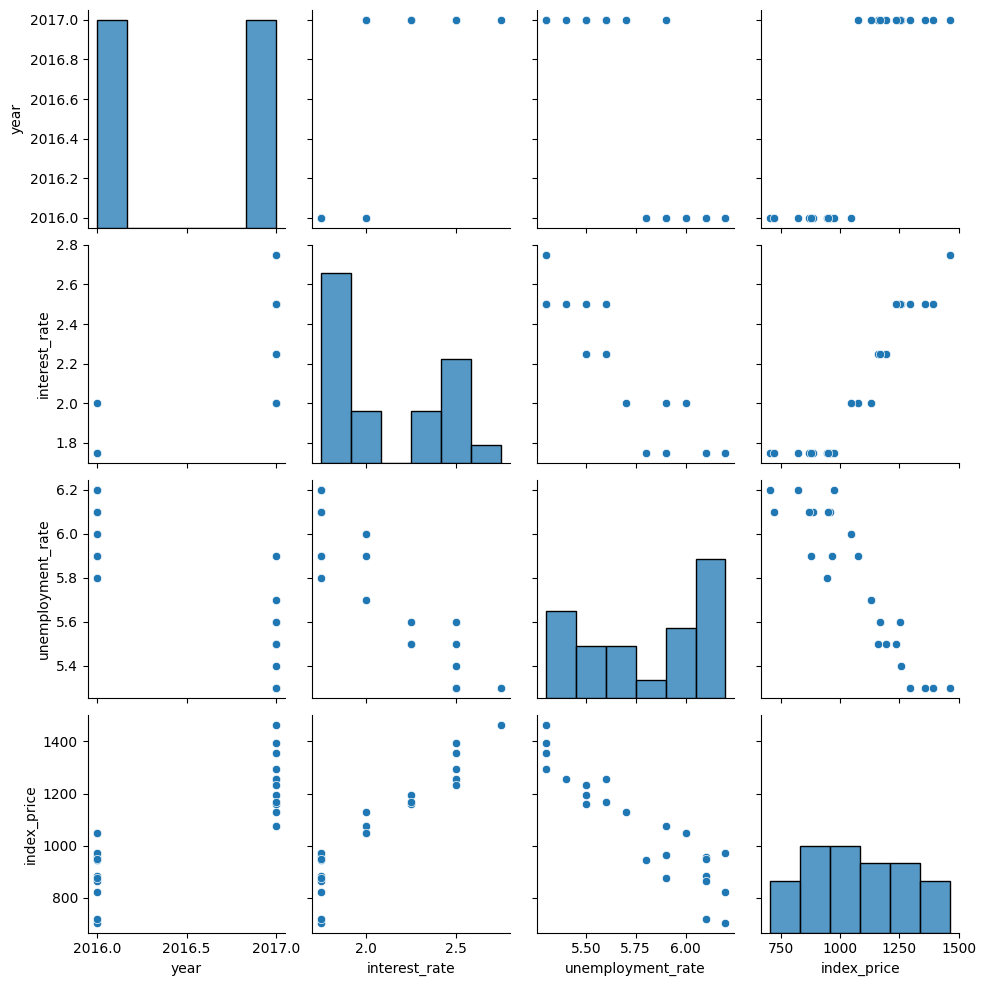

In [6]:
sns.pairplot(ei)

In [7]:
ei.corr()

,year,interest_rate,unemployment_rate,index_price
year,1.000000,0.882851,-0.877000,0.863232
interest_rate,0.882851,1.000000,-0.925814,0.935793
unemployment_rate,-0.877000,-0.925814,1.000000,-0.922338
index_price,0.863232,0.935793,-0.922338,1.000000


Text(0, 0.5, 'index_price')

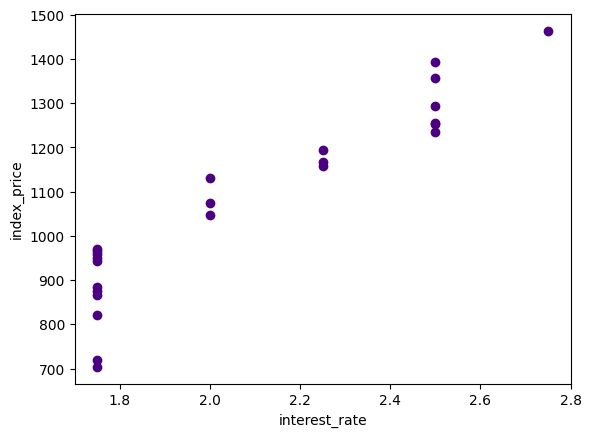

In [8]:
#visualising more datapoint closely

plt.scatter(ei['interest_rate'],ei['index_price'],color='indigo')
plt.xlabel('interest_rate')
plt.ylabel('index_price')

In [9]:
#independent and dependent features
X=ei.iloc[:,:-1]
y=ei.iloc[:,-1]
X.head()

,year,interest_rate,unemployment_rate
0,2017,2.75,5.3
1,2017,2.50,5.3
2,2017,2.50,5.3
3,2017,2.50,5.3
4,2017,2.50,5.4


In [10]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)


In [21]:
import seaborn as sns


<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

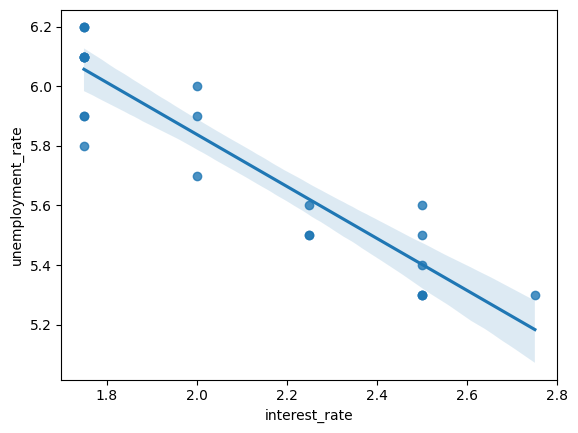

In [38]:
sns.regplot(x=ei['interest_rate'],y=ei['unemployment_rate'])

<Axes: xlabel='interest_rate', ylabel='index_price'>

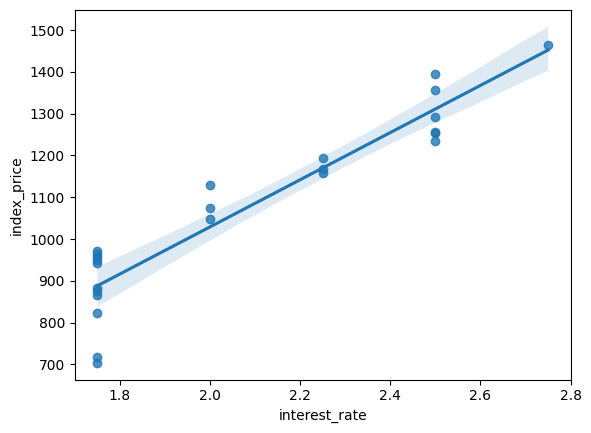

In [40]:
sns.regplot(x=ei['interest_rate'],y=ei['index_price'])


Axes(0.125,0.11;0.775x0.77)


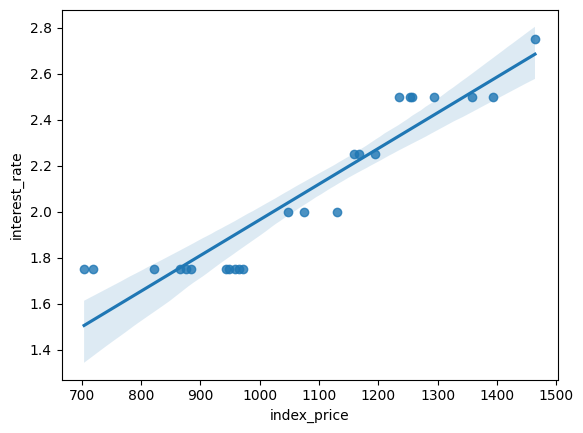

In [42]:
print(sns.regplot(x=ei['index_price'],y=ei['interest_rate']))


Axes(0.125,0.11;0.775x0.77)


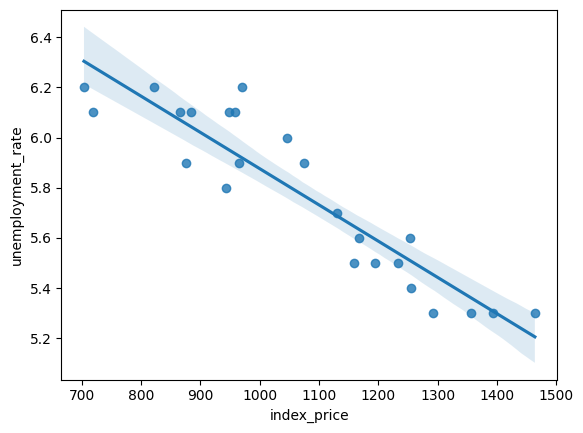

In [43]:
print(sns.regplot(x=ei['index_price'],y=ei['unemployment_rate']))

In [45]:
# now doin some scaling 
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X_train_scale=scale.fit_transform(X_train)
X_test_scale=scale.transform(X_test)

In [46]:
#now apply regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scale,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [75]:
lr.coef_

array([   8.83993865,   83.20954787, -112.85758052])

In [47]:
#cross validation
from sklearn.model_selection import cross_val_score
cvs=cross_val_score(lr,X_train_scale,y_train,scoring='neg_mean_squared_error',cv=3)


In [48]:
np.mean(cvs)

np.float64(-9661.912421929721)

In [50]:
#prediction
y_pred=lr.predict(X_test)
y_pred

C:\Users\yuvra\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([18450.10548797, 18320.66046903, 18514.28177802, 18331.94622708,
       18384.1600688 , 18438.81972992])

In [55]:
#perrformance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse,mae,rmse)

298843127.11827326 17286.662293468842 17287.079774162936


In [ ]:
score=r2_score(y_test,y_pred)
print(score)
#adjusted r-squared
print(1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

-8876.055878119689
-22191.63969529922


pltscatter <matplotlib.collections.PathCollection object at 0x0000026EB1D90910>


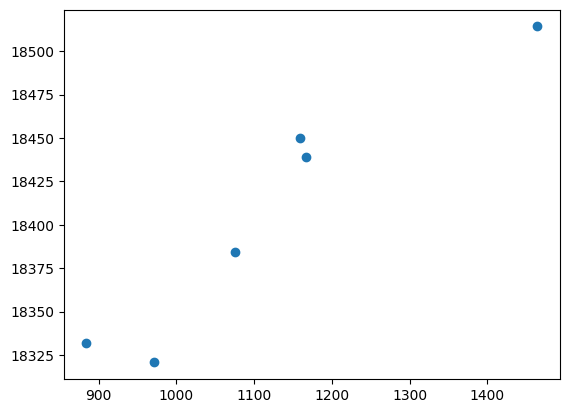

In [58]:
#assumption
pltscatter=plt.scatter(y_test,y_pred); print('pltscatter',pltscatter)




In [59]:
residual=y_test-y_pred; print('residuals',residual)


residuals 8    -17291.105488
16   -17349.660469
0    -17050.281778
18   -17447.946227
11   -17309.160069
9    -17271.819730
Name: index_price, dtype: float64


plotting the residual <seaborn.axisgrid.FacetGrid object at 0x0000026EB1DE0690>


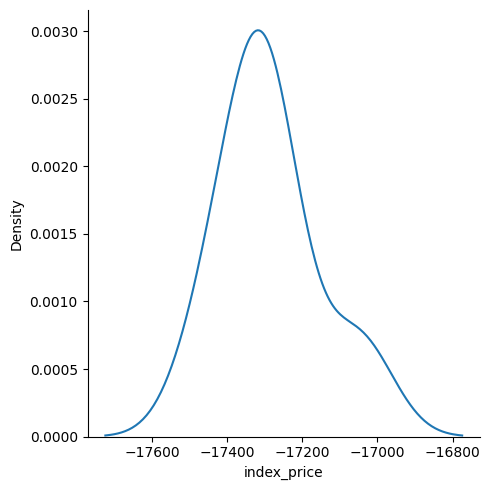

In [60]:
plotresi=sns.displot(residual,kind='kde');print('plotting the residual',plotresi)


scatter_rersi <matplotlib.collections.PathCollection object at 0x0000026EB1E88190>


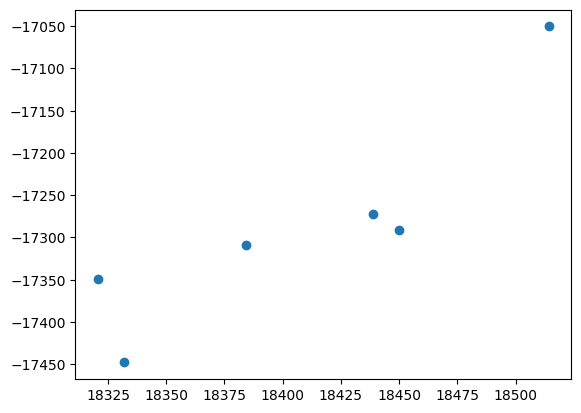

In [61]:
scatter_resi=plt.scatter(y_pred,residual);print('scatter_rersi',scatter_resi)

In [72]:
#ols linear regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train_scale).fit()

In [68]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.996
Model:                            OLS   Adj. R-squared (uncentered):              0.996
Method:                 Least Squares   F-statistic:                              1336.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):                    1.98e-18
Time:                        00:37:11   Log-Likelihood:                         -100.85
No. Observations:                  18   AIC:                                      207.7
Df Residuals:                      15   BIC:                                      210.4
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
year                  1.2896      0.494      2.609      0.020       0.236       2.343
interest_rate       259.1543    125.019      2.073      0.056      -7.318     525.627
unemployment_rate  -359.9296    130.771     -2.752      0.015    -638.662     -81.197
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   1.801
Prob(Omnibus):                  0.742   Jarque-Bera (JB):                0.564
Skew:                          -0.361   Prob(JB):                        0.754
Kurtosis:                       2.520   Cond. No.                     2.11e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.11e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [73]:
lr.coef_

array([   8.83993865,   83.20954787, -112.85758052])